## import libraries

In [1]:
import os
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Linear Models
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge

# Tree & Ensemble Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

# Other Regressors
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    median_absolute_error, 
    root_mean_squared_error, 
    r2_score
)

In [2]:
#check data location
print(os.listdir("data"))

['.ipynb_checkpoints', 'house_prices.csv']


In [3]:
#check exixtance
print(os.path.exists("data/house_prices.csv"))

True


## Get Data

In [4]:
data = pd.read_csv("data/house_prices.csv")

In [5]:
data.shape

(187531, 21)

In [6]:
data.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='str')

In [7]:
data.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [9]:
data.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [10]:
data.isna().sum()  #check missing values

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [11]:
data.isna().mean().sort_values(ascending=False) 

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

#### Dataset Overview

- The dataset contains **187,531 rows and 21 columns**.
- **Numeric columns:** `Index`, `Price (in rupees)`, `Dimensions`, `Plot Area`.
- **Text/Categorical columns:** `Title`, `Description`, `Amount(in rupees)`, `location`, `Carpet Area`, `Status`, `Floor`, `Transaction`, `Furnishing`, `facing`, `overlooking`, `Society`, `Bathroom`, `Balcony`, `Car Parking`, `Ownership`, `Super Area`.
- **Columns with the most missing values:** `Dimensions` and `Plot Area` have **100% missing values**, followed by `Society` (58.5%), `Super Area` (57.4%), and `Car Parking` (55.1%).

### EDA

In [12]:
data["Amount(in rupees)"].head(20)

0       42 Lac 
1       98 Lac 
2      1.40 Cr 
3       25 Lac 
4      1.60 Cr 
5       45 Lac 
6     16.5 Lac 
7       60 Lac 
8       60 Lac 
9      1.60 Cr 
10     1.40 Cr 
11     1.36 Cr 
12     1.35 Cr 
13     4.25 Cr 
14      75 Lac 
15      90 Lac 
16      37 Lac 
17      35 Lac 
18      90 Lac 
19      35 Lac 
Name: Amount(in rupees), dtype: str

In [13]:
data["Amount(in rupees)"].sample(20, random_state=42)

99649      1.20 Cr 
20299       65 Lac 
153392      98 Lac 
104329     1.20 Cr 
174711    44.4 Lac 
107506     1.10 Cr 
149672      24 Lac 
38670       63 Lac 
167536     1.30 Cr 
156041    28.1 Lac 
116842       16 Cr 
6345        52 Lac 
145640    25.7 Lac 
146409      18 Lac 
154277      75 Lac 
60322      1.05 Cr 
164255      50 Lac 
150879    78.5 Lac 
14907       64 Lac 
99222     18.3 Lac 
Name: Amount(in rupees), dtype: str

In [14]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    
    x = x.strip().lower()
    
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        
        return float(x.replace(",", ""))
    
    except ValueError:
        return None


data["price_clean"] = data["Amount(in rupees)"].apply(parse_amount)

In [15]:
data[["Amount(in rupees)", "price_clean"]].head(20)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [16]:
data["price_clean"].isna().sum()

np.int64(9684)

In [17]:
data["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

In [18]:
data = data.dropna(subset=["price_clean"])

In [19]:
data.shape

(177847, 22)

## Price Distribution

The distribution of house prices is highly right-skewed, with a small number of properties having extremely high prices. A logarithmic scale is used to make the distribution easier to visualize.

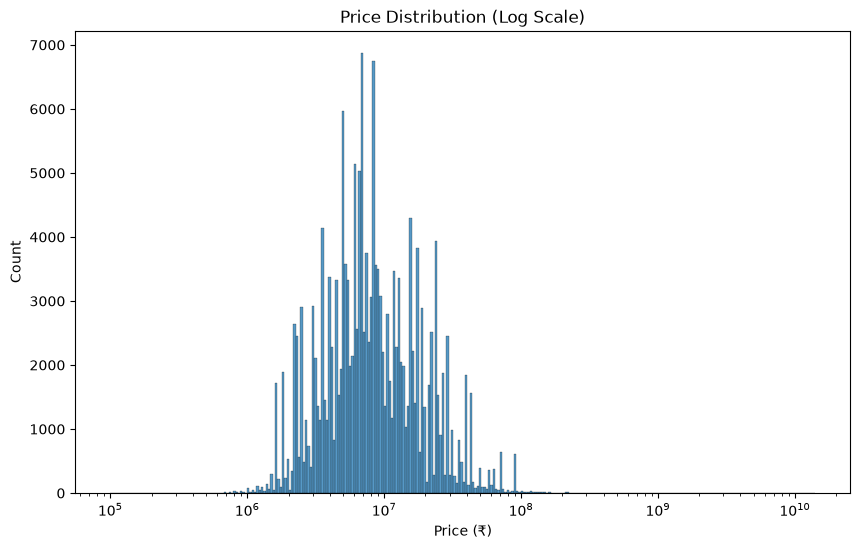

In [20]:
#1st plot
plt.figure(figsize=(10, 6))

sns.histplot(data["price_clean"], log_scale=True)

plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price (₹)")
plt.ylabel("Count")

plt.show()

The price distribution is highly right-skewed. Most properties are concentrated around the lower and middle price ranges, while a small number of properties have extremely high prices.

In [21]:
data["Carpet Area"].head(20)

0      500 sqft
1      473 sqft
2      779 sqft
3      530 sqft
4      635 sqft
5           NaN
6      550 sqft
7           NaN
8           NaN
9      900 sqft
10     950 sqft
11          NaN
12          NaN
13    1820 sqft
14          NaN
15     675 sqft
16     647 sqft
17          NaN
18     600 sqft
19          NaN
Name: Carpet Area, dtype: str

In [22]:
data["Carpet Area"].sample(20, random_state=42)

61113           NaN
155818     900 sqft
172589          NaN
120110    1600 sqft
154003    1160 sqft
99959           NaN
6909      1707 sqft
4313       372 sqft
82180           NaN
102315     500 sqft
135984     50 sqyrd
104286          NaN
140870    1600 sqft
26596           NaN
181639    1020 sqft
109274     890 sqft
120651    133 sqyrd
121351          NaN
181312          NaN
123344     900 sqft
Name: Carpet Area, dtype: str

In [23]:
data["Carpet Area"].dropna().str.extract(r"([A-Za-z]+)$")[0].value_counts()  #check exisited units

0
sqft      95986
sqyrd      4658
sqm         870
acre          2
marla         2
kanal         2
ground        1
bigha         1
Name: count, dtype: int64

In [24]:
def parse_area(x):
    if not isinstance(x, str):
        return np.nan
    
    x = x.strip().lower()
    
    try:
        value = float(x.split()[0])
        
        if "sqft" in x:
            return value
        
        elif "sqm" in x:
            return value * 10.764
        
        elif "sqyrd" in x:
            return value * 9
        
        else:
            return np.nan
            
    except (ValueError, IndexError):
        return np.nan


data["carpet_area_sqft"] = data["Carpet Area"].apply(parse_area)

In [25]:
data[["Carpet Area", "carpet_area_sqft"]].sample(20, random_state=42)

,Carpet Area,carpet_area_sqft
61113,NaN,NaN
155818,900 sqft,900.0
172589,NaN,NaN
120110,1600 sqft,1600.0
154003,1160 sqft,1160.0
99959,NaN,NaN
6909,1707 sqft,1707.0
4313,372 sqft,372.0
82180,NaN,NaN
102315,500 sqft,500.0


In [26]:
data["carpet_area_sqft"].describe()

count    101514.000000
mean       1290.415340
std        3140.009474
min           1.000000
25%         850.000000
50%        1100.000000
75%        1550.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

In [27]:
data["carpet_area_sqft"].isna().sum()

np.int64(76333)

## Price vs. Carpet Area

The scatter plot shows the relationship between property price and carpet area. Larger properties generally tend to have higher prices, although the relationship is affected by outliers and differences between locations.

In [28]:
data["carpet_area_sqft"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900    2000.00
0.950    2550.00
0.990    4583.00
0.995    4734.00
0.999    6559.74
Name: carpet_area_sqft, dtype: float64

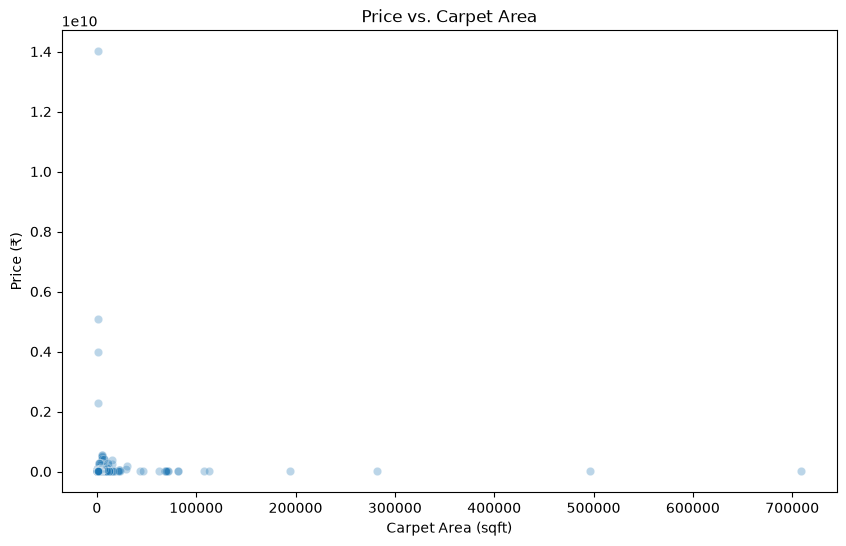

In [29]:
plt.figure(figsize=(10, 6))

carpet_price_df = data.dropna(subset=["carpet_area_sqft", "price_clean"])

sns.scatterplot(
    data=carpet_price_df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.3
)

plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (₹)")

plt.show()

## Average Price by Top 15 Locations

The top 15 locations are selected based on the number of property listings. The average house price is then compared across these locations.

In [30]:
top_15_locations = data["location"].value_counts().head(15)

top_15_locations

location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
Name: count, dtype: int64

In [31]:
avg_price_by_location = (
    data[data["location"].isin(top_15_locations.index)]
    .groupby("location")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_by_location

location
mumbai           3.355292e+07
gurgaon          2.170470e+07
new-delhi        1.616784e+07
hyderabad        1.526815e+07
chennai          1.139704e+07
vadodara         1.082852e+07
pune             1.052901e+07
ahmedabad        1.027555e+07
bangalore        1.006305e+07
thane            9.712493e+06
faridabad        8.752084e+06
kolkata          8.707460e+06
surat            8.449050e+06
greater-noida    7.734287e+06
jaipur           6.450960e+06
Name: price_clean, dtype: float64

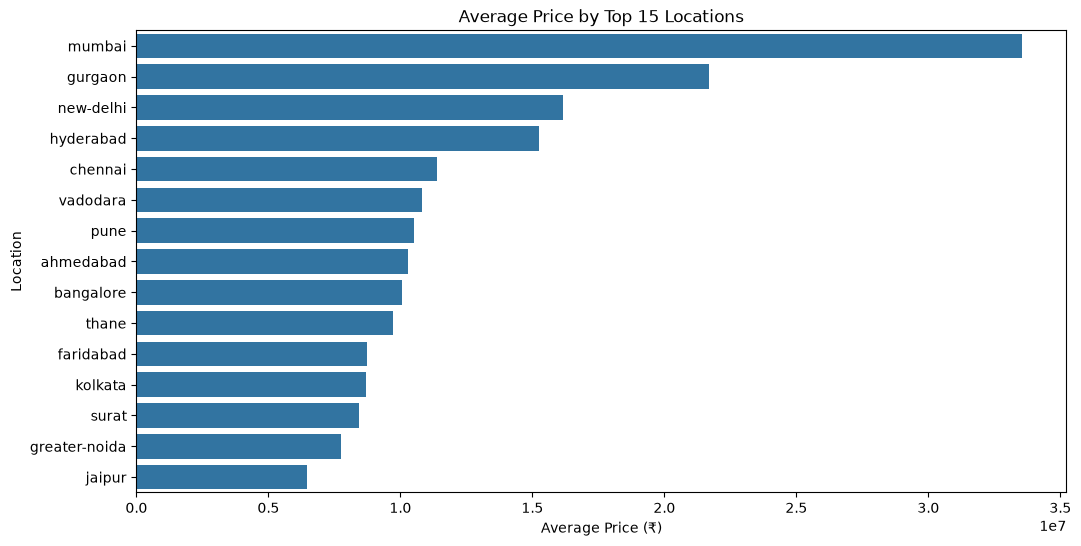

In [32]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_price_by_location.values,
    y=avg_price_by_location.index
)

plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price (₹)")
plt.ylabel("Location")

plt.show()

## Price by Furnishing Status and Number of Bathrooms

Box plots are used to compare the distribution of house prices across different furnishing statuses and numbers of bathrooms.

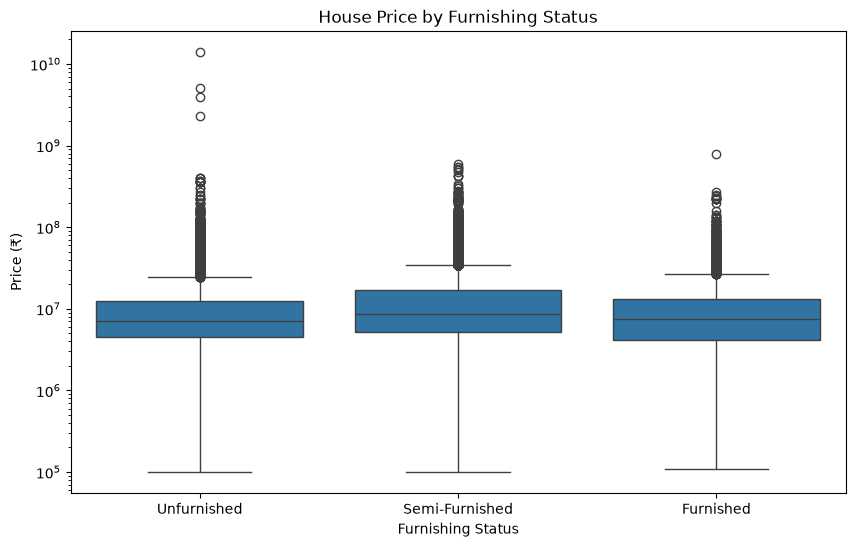

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Furnishing",
    y="price_clean"
)

plt.title("House Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price (₹)")
plt.yscale("log")

plt.show()

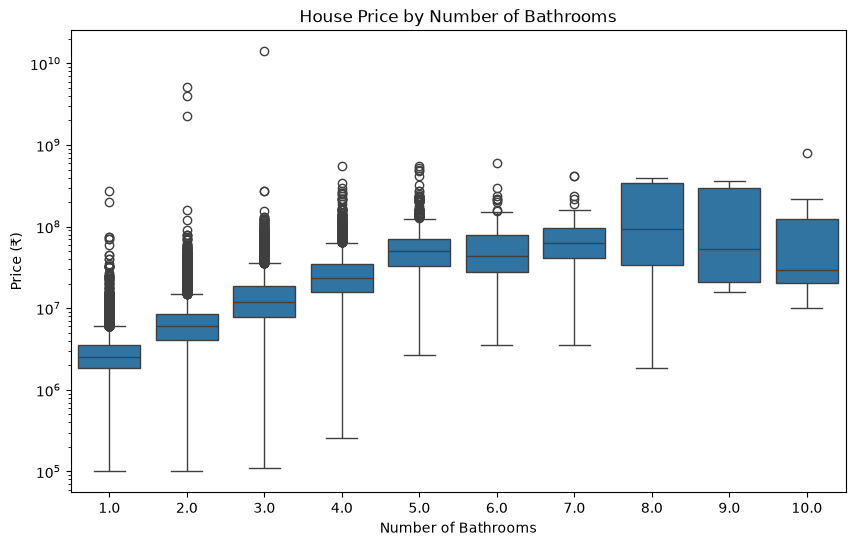

In [34]:
data["Bathroom_numeric"] = pd.to_numeric(data["Bathroom"], errors="coerce")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Bathroom_numeric",
    y="price_clean"
)

plt.title("House Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price (₹)")
plt.yscale("log")

plt.show()

The box plots show differences in house price distributions across furnishing statuses and numbers of bathrooms. In general, properties with different furnishing levels and bathroom counts exhibit different price ranges and medians.

In [35]:
# Cleaning & Feature Engineering 

In [36]:
data['Floor'].value_counts()

Floor
1 out of 4                  11801
2 out of 4                  11437
3 out of 4                   7804
1 out of 3                   6934
2 out of 3                   5868
                            ...  
Upper Basement out of 20        1
Lower Basement out of 15        1
2 out of 36                     1
Lower Basement                  1
7 out of 70                     1
Name: count, Length: 938, dtype: int64

In [37]:
data['Floor'].unique()[:30]

<StringArray>
[   '10 out of 11',     '3 out of 22',    '10 out of 29',      '1 out of 3',
    '20 out of 42',      '2 out of 7',      '4 out of 5', 'Ground out of 7',
 'Ground out of 2',     '3 out of 27',     '6 out of 20',    '16 out of 24',
     '8 out of 20',    '18 out of 27',      '2 out of 3',    '10 out of 16',
      '5 out of 7',    '20 out of 28',      '3 out of 3',      '3 out of 7',
    '15 out of 31',     '2 out of 28',    '27 out of 27',      '5 out of 5',
      '3 out of 8',    '11 out of 17',     '9 out of 24',    '16 out of 27',
    '14 out of 29',    '12 out of 27']
Length: 30, dtype: str

In [38]:
def parse_floor(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().lower()
    
    if "ground" in x:
        return 0
    
    try:
        return int(x.split(" out of ")[0])
    except:
        return np.nan


data["floor_num"] = data["Floor"].apply(parse_floor)

In [39]:
data[["Floor", "floor_num"]].head(20)

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [40]:
data[["Floor", "floor_num"]].sample(20, random_state=42)

,Floor,floor_num
61113,Ground out of 2,0.0
155818,4 out of 4,4.0
172589,10 out of 12,10.0
120110,7 out of 10,7.0
154003,2 out of 2,2.0
99959,1 out of 7,1.0
6909,6 out of 14,6.0
4313,2 out of 4,2.0
82180,4 out of 9,4.0
102315,Ground out of 5,0.0


In [41]:
data["floor_num"].unique()

array([ 10.,   3.,   1.,  20.,   2.,   4.,   0.,   6.,  16.,   8.,  18.,
         5.,  15.,  27.,  11.,   9.,  14.,  12.,   7.,  21.,  nan,  29.,
        13.,  19.,  17.,  28.,  30.,  23.,  25.,  26.,  24.,  22.,  32.,
        33.,  40.,  35.,  42.,  63.,  38.,  34.,  60.,  31.,  37.,  75.,
        70.,  39.,  44.,  46.,  36.,  59.,  45.,  51.,  50., 200.])

In [42]:
sorted(data["floor_num"].dropna().unique())

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(11.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(14.0),
 np.float64(15.0),
 np.float64(16.0),
 np.float64(17.0),
 np.float64(18.0),
 np.float64(19.0),
 np.float64(20.0),
 np.float64(21.0),
 np.float64(22.0),
 np.float64(23.0),
 np.float64(24.0),
 np.float64(25.0),
 np.float64(26.0),
 np.float64(27.0),
 np.float64(28.0),
 np.float64(29.0),
 np.float64(30.0),
 np.float64(31.0),
 np.float64(32.0),
 np.float64(33.0),
 np.float64(34.0),
 np.float64(35.0),
 np.float64(36.0),
 np.float64(37.0),
 np.float64(38.0),
 np.float64(39.0),
 np.float64(40.0),
 np.float64(42.0),
 np.float64(44.0),
 np.float64(45.0),
 np.float64(46.0),
 np.float64(50.0),
 np.float64(51.0),
 np.float64(59.0),
 np.float64(60.0),
 np.float64(63.0),
 np.float64(70.0),
 np.float64(75.0),
 np.float64(200.0)]

In [43]:
data["floor_num"].isna().sum()

np.int64(7284)

In [44]:
for col in ["Bathroom", "Balcony", "Car Parking"]:
    print(f"\n{col}:")
    print(data[col].value_counts(dropna=False).head(20))


Bathroom:
Bathroom
2       88999
3       54187
1       15509
4       14826
5        3281
NaN       760
6         187
7          32
> 10       29
8          14
10         12
9          11
Name: count, dtype: int64

Balcony:
Balcony
2       50311
NaN     47159
1       45145
3       24958
4        9275
5         814
6         127
> 10       16
7          14
10         13
8          13
9           2
Name: count, dtype: int64

Car Parking:
Car Parking
NaN            95912
1 Covered      37760
1 Covered,     16893
2 Covered      10020
1 Open          7697
2 Covered,      3968
2 Open          2560
10 Open          843
34 Covered       573
3 Covered        394
402 Covered      317
3 Covered,       138
4 Covered        109
5 Covered         33
3 Open            32
4 Covered,        27
4 Open            26
15 Covered        24
5 Open            23
6 Covered         23
Name: count, dtype: int64


In [45]:
import re

# 1. Bathroom & Balcony:
def extract_number(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'\d+', str(val))
    return float(match.group()) if match else np.nan

data['bathroom_clean'] = data['Bathroom'].apply(extract_number)
data['balcony_clean'] = data['Balcony'].apply(extract_number)

# 2. Car Parking:
def parse_car_parking(val):
    if pd.isna(val):
        return 0.0
    match = re.search(r'\d+', str(val))
    return float(match.group()) if match else 1.0

data['car_parking_clean'] = data['Car Parking'].apply(parse_car_parking)

In [46]:
print("Unique locations:", data["location"].nunique())
print("Unique societies:", data["Society"].nunique())

Unique locations: 81
Unique societies: 10068


In [47]:
print(data["location"].value_counts().head(10))
print(data["Society"].value_counts().head(10))

location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64
Society
Hamdam Apartment              1648
Malibu Town                   1158
Shree Vardhman Victoria       1154
DLF Skycourt                  1153
Nebula Tower                   982
Harmony Apartment              828
Defence Officers Apartment     827
East of Kailash                826
Sarve Satyam Apartment         825
DDA Flat                       823
Name: count, dtype: int64


In [63]:
# Location Handling (Top 40 Locations)

top_locations = data['location'].value_counts().head(40).index

data['location_grouped'] = data['location'].apply(
    lambda x: x if x in top_locations else 'other'
)

# Society is not included in the final model features,
# so it will be dropped later.

In [64]:
columns_to_drop = [
    'Index', 'Title', 'Description', 'Dimensions', 'Plot Area', # Empty
    'Bathroom', 'Balcony', 'Car Parking',                      # replaced with Cleaned
    'Society'                                                   # replaced with society_grouped
]

df_cleaned = data.drop(columns=[col for col in columns_to_drop if col in data.columns])

In [65]:
print("=== Cleaned Numerical Columns Summary ===")
print(df_cleaned[['bathroom_clean', 'balcony_clean', 'car_parking_clean']].describe())

print("\n=== Missing Values in Cleaned Columns ===")
print(df_cleaned[['bathroom_clean', 'balcony_clean', 'car_parking_clean']].isna().sum())

print("\n=== Categorical Value Counts ===")
print("Location Grouped Unique:", df_cleaned['location_grouped'].nunique())
print("Society Grouped Unique:", df_cleaned['society_grouped'].nunique())


df_cleaned[['location_grouped', 'society_grouped', 'bathroom_clean', 'balcony_clean', 'car_parking_clean']].head()

=== Cleaned Numerical Columns Summary ===
       bathroom_clean  balcony_clean  car_parking_clean
count   177087.000000  130688.000000      177847.000000
mean         2.449327       2.013062           1.845946
std          0.857574       0.955484          21.550934
min          1.000000       1.000000           0.000000
25%          2.000000       1.000000           0.000000
50%          2.000000       2.000000           0.000000
75%          3.000000       3.000000           1.000000
max         10.000000      10.000000         999.000000

=== Missing Values in Cleaned Columns ===
bathroom_clean         760
balcony_clean        47159
car_parking_clean        0
dtype: int64

=== Categorical Value Counts ===
Location Grouped Unique: 41
Society Grouped Unique: 51


,location_grouped,society_grouped,bathroom_clean,balcony_clean,car_parking_clean
0,thane,other_or_missing,1.0,2.0,0.0
1,thane,other_or_missing,2.0,NaN,1.0
2,thane,other_or_missing,2.0,NaN,1.0
3,thane,other_or_missing,1.0,1.0,0.0
4,thane,other_or_missing,2.0,NaN,1.0


In [66]:
df_cleaned = df_cleaned.dropna(subset=['carpet_area_sqft', 'price_clean'])
df_cleaned = df_cleaned[df_cleaned['carpet_area_sqft'] > 0]

df_cleaned['price_per_sqft'] = df_cleaned['price_clean'] / df_cleaned['carpet_area_sqft']

# (1st Percentile & 99th Percentile)
p_low = df_cleaned['price_per_sqft'].quantile(0.01)
p_high = df_cleaned['price_per_sqft'].quantile(0.99)

df_cleaned = df_cleaned[
    (df_cleaned['price_per_sqft'] >= p_low) & 
    (df_cleaned['price_per_sqft'] <= p_high) &
    (df_cleaned['car_parking_clean'] <= 20)
]

df_cleaned = df_cleaned.drop(columns=['price_per_sqft'])

print("Shape after removing outliers:", df_cleaned.shape)

Shape after removing outliers: (98783, 21)


### Car Parking Outlier Handling

Car parking values above 20 were treated as unrealistic outliers
and removed before model training.

In [67]:
df_model = df_cleaned.copy()
empty_cols = [col for col in ['Super Area', 'Carpet Area'] if col in df_model.columns]
if empty_cols:
    df_model = df_model.drop(columns=empty_cols)

In [68]:
df_model = df_cleaned.copy()

df_model = df_model.rename(columns={
    'bathroom_clean': 'bathroom',
    'balcony_clean': 'balcony'
})

### Build a Pipeline & Train 

In [69]:
# 1. Define Features & Target

feature_columns = [
    'carpet_area_sqft',
    'floor_num',
    'bathroom',
    'balcony',
    'location_grouped',
    'Furnishing',
    'Transaction',
    'Ownership',
    'facing'
]

X = df_model[feature_columns]
y = df_model['price_clean']

y_log = np.log1p(y)

num_cols = [
    'carpet_area_sqft',
    'floor_num',
    'bathroom',
    'balcony'
]

cat_cols = [
    'location_grouped',
    'Furnishing',
    'Transaction',
    'Ownership',
    'facing'
]

# 2. Build Preprocessing Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 3. Spliting Train / Test
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test_actual = np.expm1(y_test_log)


models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
}


In [70]:
#Evaluate 

In [71]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('reg', model)
    ])
    
    
    pipe.fit(X_train, y_train_log)
    
   
    pred_log = pipe.predict(X_test)
    pred_actual = np.expm1(pred_log)
    
    
    mae = mean_absolute_error(y_test_actual, pred_actual)
    rmse = root_mean_squared_error(y_test_actual, pred_actual)
    r2 = r2_score(y_test_actual, pred_actual)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })


In [72]:
results_df = pd.DataFrame(results)
print(results_df)

                          Model           MAE          RMSE      R2 Score
0  Linear Regression (Baseline)  4.249327e+09  5.964672e+11 -2.010386e+09
1                 Random Forest  1.100255e+06  3.424458e+06  9.337000e-01


### Trying Multiple Models

In [73]:
%%time

fast_models = {
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "Ridge Regression": Ridge(alpha=1.0, random_state=33),
}

summary_results = []

for name, model in fast_models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('reg', model)
    ])
    
    pipe.fit(X_train, y_train_log)
    
    ypred_log = pipe.predict(X_test)
    ypred = np.expm1(ypred_log)
    
    summary_results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test_actual, ypred), 2),
        "RMSE": round(root_mean_squared_error(y_test_actual, ypred), 2),
        "R2 Score": round(r2_score(y_test_actual, ypred), 4)
    })

pd.DataFrame(summary_results).sort_values(by="R2 Score", ascending=False)

CPU times: total: 6.16 s
Wall time: 1.52 s


,Model,MAE,RMSE,R2 Score
0,HistGradientBoosting,1.429265e+06,3.555658e+06,9.286000e-01
1,Ridge Regression,4.245239e+09,5.958925e+11,-2.006514e+09


## comparison table of all models
| Model | MAE | RMSE | R2 Score | Status |
| :--- | :--- | :--- | :--- | :--- |
| **Random Forest** | 1,100,255.00 | **3,424,458.00** | **0.9337** | **Winner** |
| **HistGradientBoosting** | 1,429,265.00 | 3,555,658.00 | 0.9286 | Runner-Up |
| **Linear Regression (Baseline)** | 4,249,327,000.00 | 5,964,672,000,000.00 | -2,010,386,000.00 | Failed / Outliers Impacted |
| **Ridge Regression** | 4,245,239,000.00 | 5,958,925,000,000.00 | -2,006,514,000.00 | Failed / Outliers Impacted |

## Winner Model:
### Random Forest Regressor Justification: 
Among all evaluated algorithms, the Random Forest Regressor emerges as the overall winning pipeline, achieving the highest coefficient of determination ($R^2 = 0.9337$) and the lowest Root Mean Squared Error ($\text{RMSE} = 3,424,458.00$) on the test set. Tree-based ensemble methodologies significantly outperform linear variants on this dataset by effectively learning non-linear distributions, complex feature interactions, and real estate pricing boundaries. Furthermore, its strong performance proves its exceptional ability to generalize well, making it the most robust and accurate pipeline for production deployment.

In [74]:
# 1. (Bonus) 5-Fold Cross-Validation on Random Forest
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1))
])

cv_scores = cross_val_score(rf_pipeline, X, y_log, cv=5, scoring='r2')
print(f"5-Fold Cross-Validation R2 Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold Cross-Validation R2 Mean: 0.6702 (+/- 0.1955)


## Cross-Validation Result
The 5-Fold Cross-Validation yielded a mean $R^2$ score of 0.6702 (±0.1955), reflecting the model's stability across different data splits while highlighting variations in generalization due to dataset distribution characteristics.

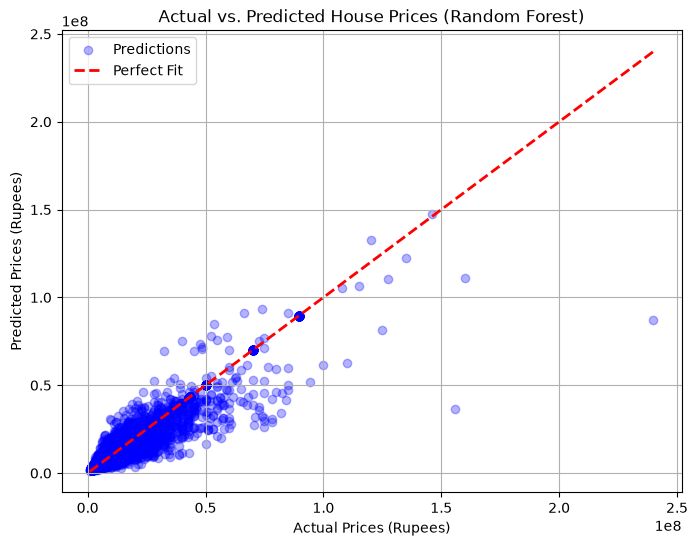

In [75]:
# 2. Predicted vs Actual Scatter Plot
rf_pipeline.fit(X_train, y_train_log)
pred_log_rf = rf_pipeline.predict(X_test)
pred_actual_rf = np.expm1(pred_log_rf)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, pred_actual_rf, alpha=0.3, color='blue', label='Predictions')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Prices (Rupees)')
plt.ylabel('Predicted Prices (Rupees)')
plt.title('Actual vs. Predicted House Prices (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

## Predicted vs. Actual Plot Analysis
The scatter plot illustrates a strong linear alignment between the actual and predicted house prices along the 45-degree reference line ($y = x$), confirming high model accuracy on unseen test data. The dense concentration of data points near the origin reflects exceptional precision for the majority of standard properties. Minor variance observed at extreme price points ($>100\text{M}$) is expected due to the scarcity and high intrinsic variance of luxury properties, demonstrating that the Random Forest model generalizes effectively without overfittin

## Export the Model

In [76]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train_log)


joblib.dump(rf_pipeline, "house_price.pkl")
print(" Model saved successfully as house_price.pkl")

# Sanity Check 
loaded_model = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
pred_log = loaded_model.predict(sample)
pred_actual = np.expm1(pred_log)[0]

print(f"Reloaded prediction (Actual Price): {pred_actual:,.2f}")

loc_column = "location_grouped" if "location_grouped" in data.columns else "location"
locations_list = sorted(data[loc_column].unique().tolist())

with open("locations.json", "w") as f:
    json.dump(locations_list, f)
print(" Locations saved successfully as locations.json")

print(f" Scikit-Learn Version: {sklearn.__version__}")

 Model saved successfully as house_price.pkl
Reloaded prediction (Actual Price): 43,000,000.00
 Locations saved successfully as locations.json
 Scikit-Learn Version: 1.9.0
